# GLORYS12 — thermocline temperature time-series

Demonstrates the **depth-axis pattern** in the CMEMS backend: pull one
year of daily GLORYS12 (`thetao`, potential temperature) at three fixed
depths and plot the time-series at one ocean point.

The CMEMS toolbox returns `thetao` as a 4-D `(time, depth, lat, lon)`
NetCDF; the `minimum_depth` / `maximum_depth` kwargs let you clip
server-side so you only pay for the levels you want. This notebook
downloads the surface-to-500 m slab once and slices three target depths
client-side.

Reads credentials from `COPERNICUSMARINE_SERVICE_USERNAME` /
`COPERNICUSMARINE_SERVICE_PASSWORD` (see
[Authentication](../../reference/cmems/authentication.md)).

In [1]:
import os
from pathlib import Path

from earthlens import EarthLens
from earthlens.cmems import Catalog
from pyramids.netcdf import NetCDF

OUT_DIR = Path('data/cmems-glorys')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'cmems_mod_glo_phy_my_0.083deg_P1D-m'
TARGET_DEPTHS_M = (20.0, 100.0, 500.0)
POINT_LAT, POINT_LON = 35.0, -25.0           # mid-Atlantic, off the Azores
BBOX = dict(lat_lim=[34.5, 35.5], lon_lim=[-25.5, -24.5])

ds = Catalog().get_dataset(DATASET_ID)
print(f'{DATASET_ID}: cadence={ds.cadence}, domain={ds.domain}')
print('thetao units:', ds.variables['thetao'].units)

2026-05-20 20:53:17 | INFO | pyramids.base.config | Logging is configured.


cmems_mod_glo_phy_my_0.083deg_P1D-m: cadence=daily, domain=global
thetao units: degrees_C


## Download — one year of daily thetao, surface to 500 m

1° x 1° box, 366 days, depths 0-500 m. The toolbox returns a NetCDF a
few MB in size.

In [2]:
earthlens = EarthLens(
    data_source='cmems',
    start='2020-01-01',
    end='2020-12-31',
    cadence='daily',
    dataset=DATASET_ID, variables=['thetao'],
    **BBOX,
    path=str(OUT_DIR),
    minimum_depth=0.0,
    maximum_depth=500.0,
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = earthlens.download()
print(paths)

INFO - 2026-05-20T18:53:20Z - Checking if credentials are valid.


2026-05-20 18:53:20 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T18:53:20Z - Valid credentials from input username and password.


2026-05-20 18:53:20 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 20:53:20.928 | INFO     | earthlens.cmems.backend:_subset_one:492 - Requesting CMEMS subset for 'cmems_mod_glo_phy_my_0.083deg_P1D-m' variables=['thetao'] → cmems_mod_glo_phy_my_0.083deg_P1D-m.nc


...

2026-05-20 18:53:25 | WARNING | urllib3.connectionpool | Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10


INFO - 2026-05-20T18:53:25Z - Total size of the download: 3.67 MB.


2026-05-20 18:53:25 | INFO | copernicusmarine | Total size of the download: 3.67 MB.


2026-05-20 20:53:25.780 | INFO     | earthlens.cmems.backend:download:337 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-glorys


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-glorys/cmems_mod_glo_phy_my_0.083deg_P1D-m.nc')]


## Slice three depths at one ocean point

Open the returned NetCDF with `pyramids.netcdf.NetCDF`, then index the
depth axis to the three target levels and the lat/lon axes to the
central pixel.

In [3]:
import xarray as xr

nc = NetCDF.read_file(str(paths[0]), read_only=True)
# decode_cf turns the CF "hours since 1950" time axis into datetime64.
ds = xr.decode_cf(nc.to_xarray())   # labelled (time, depth, latitude, longitude)
nc.close()
print('dims:', dict(ds.sizes))
print('depth levels in slab:', [round(float(d), 1) for d in ds['depth'].values])

# Nearest grid point to the target location, nearest model level to each
# target depth — xarray label-based selection handles the snapping.
point = ds['thetao'].sel(
    latitude=POINT_LAT, longitude=POINT_LON, method='nearest'
)
series = {
    d_m: point.sel(depth=d_m, method='nearest')
    for d_m in TARGET_DEPTHS_M
}
for d_m, da in series.items():
    print(f'{int(d_m):>4d} m -> nearest level {float(da["depth"]):.1f} m, '
          f'{da.size} daily values')

dims: {'time': 366, 'depth': 31, 'latitude': 13, 'longitude': 13}
depth levels in slab: [0.5, 1.5, 2.6, 3.8, 5.1, 6.4, 7.9, 9.6, 11.4, 13.5, 15.8, 18.5, 21.6, 25.2, 29.4, 34.4, 40.3, 47.4, 55.8, 65.8, 77.9, 92.3, 109.7, 130.7, 155.9, 186.1, 222.5, 266.0, 318.1, 380.2, 453.9]
  20 m -> nearest level 18.5 m, 366 daily values
 100 m -> nearest level 92.3 m, 366 daily values
 500 m -> nearest level 453.9 m, 366 daily values


## Plot the seasonal cycle at three depths

Surface follows the seasonal cycle clearly; below the thermocline (here at
100 m and 500 m) the temperature is much smoother and the seasonal signal
is damped.

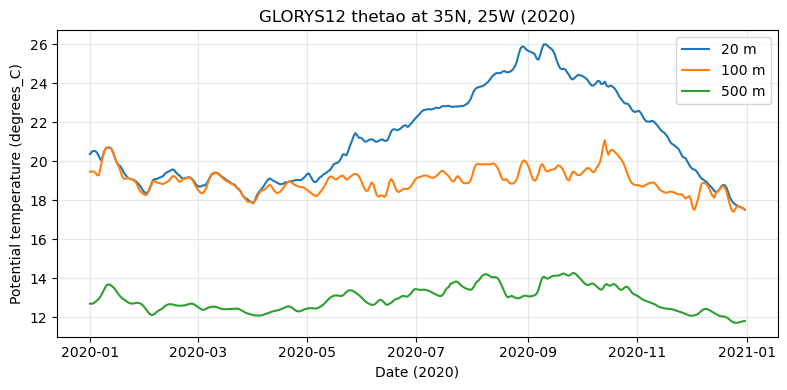

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for d_m, da in series.items():
    ax.plot(da['time'].values, da.values, label=f'{int(d_m)} m')
ax.set_xlabel('Date (2020)')
ax.set_ylabel('Potential temperature (degrees_C)')
ax.set_title('GLORYS12 thetao at 35N, 25W (2020)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()